In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: Load and Audit the Data
# ==========================================

# Load datasets (replace with your actual local file paths if needed)
print("Loading datasets...")
file_a = pd.read_csv("historical_data.csv")
file_b  = pd.read_csv("fear_greed_index.csv")


Loading datasets...


In [26]:


print(sentiment_df.head())
print(trader_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [29]:

# 2. SMART IDENTIFIER (Automatically sorts the datasets)
# The trader dataset has 16 columns, the sentiment one only has 4.
if len(file_a.columns) > 10:
    trader_df = file_a.copy()
    sentiment_df = file_b.copy()
    print("Auto-detected: file_a is Trader Data, file_b is Sentiment Data.")
else:
    trader_df = file_b.copy()
    sentiment_df = file_a.copy()
    print("Auto-detected: file_b is Trader Data, file_a is Sentiment Data.")

# 3. BULLETPROOF COLUMN CLEANING
sentiment_df.columns = sentiment_df.columns.str.lower().str.strip()
trader_df.columns = trader_df.columns.str.lower().str.strip().str.replace(' ', '_')

# 4. TIME CONVERSION & ALIGNMENT
# Trader time (using 'timestamp' from your printout)
trader_df['datetime'] = pd.to_datetime(trader_df['timestamp'], unit='ms')
trader_df['date'] = trader_df['datetime'].dt.floor('D') 

# Sentiment time
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Merge on the 'date' column
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='left')

# 5. CALCULATE DAILY METRICS
def calculate_win_rate(pnl_series):
    return (pnl_series > 0).sum() / len(pnl_series) if len(pnl_series) > 0 else 0

def calculate_long_ratio(side_series):
    longs = side_series.str.upper().isin(['BUY', 'B', 'LONG']).sum()
    return longs / len(side_series) if len(side_series) > 0 else 0

daily_trader_metrics = merged_df.groupby(['account', 'date']).agg(
    daily_pnl=('closed_pnl', 'sum'),
    win_rate=('closed_pnl', calculate_win_rate),
    avg_trade_size_usd=('size_usd', 'mean'), 
    trade_count=('account', 'count'),
    long_ratio=('side', calculate_long_ratio),
    sentiment=('classification', 'first')
).reset_index()

print("\nData Prep Complete! Here is your clean dataset:")
display(daily_trader_metrics.head())

Auto-detected: file_a is Trader Data, file_b is Sentiment Data.

Data Prep Complete! Here is your clean dataset:


,account,date,daily_pnl,win_rate,avg_trade_size_usd,trade_count,long_ratio,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,0.025974,14810.891818,462,0.300866,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,0.405542,16345.241940,3356,0.468415,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,0.531250,2492.749906,320,0.453125,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,0.435041,1693.351684,3533,0.432494,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,0.442369,1533.468395,3427,0.403268,None


--- Average Daily Metrics by Sentiment ---


,avg_daily_pnl,avg_win_rate,avg_trade_count,avg_long_ratio,avg_size_usd
sentiment,,,,,
Extreme Greed,35393.0984,0.3366,1392.4000,0.5185,4344.4478
Fear,209372.6622,0.4159,4183.4688,0.4594,5926.5227
Greed,99675.5167,0.3741,1134.0312,0.4958,5839.3110
Neutral,19842.7973,0.2607,892.6250,0.4690,3793.4442


C:\Users\kaleo\AppData\Local\Temp\ipykernel_14816\2562759680.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analysis_df, x='sentiment', y='win_rate', estimator=np.mean, palette='coolwarm')


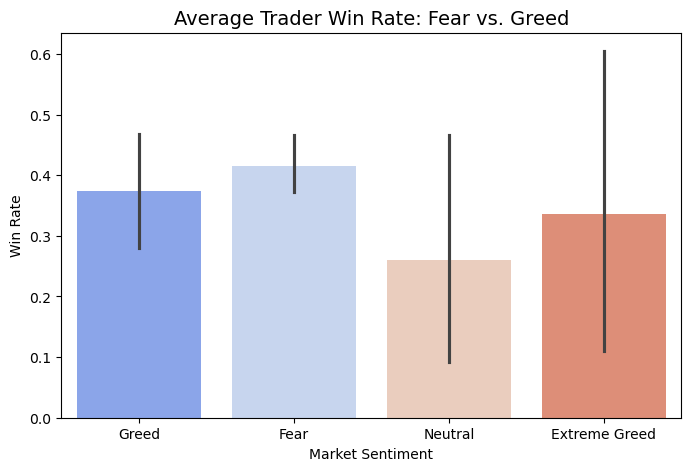

In [30]:


# 1. Clean up missing sentiment (e.g., weekends if sentiment data didn't cover it)
analysis_df = daily_trader_metrics.dropna(subset=['sentiment']).copy()

# 2. Print a summary table for the write-up
print("--- Average Daily Metrics by Sentiment ---")
sentiment_summary = analysis_df.groupby('sentiment').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean'),
    avg_long_ratio=('long_ratio', 'mean'),
    avg_size_usd=('avg_trade_size_usd', 'mean')
).round(4)
display(sentiment_summary)

# 3. Visual 1: Win Rate by Sentiment
plt.figure(figsize=(8, 5))
sns.barplot(data=analysis_df, x='sentiment', y='win_rate', estimator=np.mean, palette='coolwarm')
plt.title('Average Trader Win Rate: Fear vs. Greed', fontsize=14)
plt.ylabel('Win Rate')
plt.xlabel('Market Sentiment')
plt.show()

In [31]:
# 1. Aggregate lifetime stats per account
account_stats = analysis_df.groupby('account').agg(
    total_trades=('trade_count', 'sum'),
    overall_win_rate=('win_rate', 'mean')
)

# 2. Create Segments
median_trades = account_stats['total_trades'].median()

# Segment 1: Frequent vs Infrequent
account_stats['activity_segment'] = np.where(
    account_stats['total_trades'] >= median_trades, 'Frequent', 'Infrequent'
)

# Segment 2: Consistent Winners vs Inconsistent
account_stats['profitability_segment'] = np.where(
    account_stats['overall_win_rate'] >= 0.50, 'Consistent Winner', 'Inconsistent'
)

# 3. Merge these labels back into our daily analysis dataframe
analysis_df = analysis_df.merge(
    account_stats[['activity_segment', 'profitability_segment']], 
    on='account', 
    how='left'
)

print("\nTrader Segments Created successfully!")
display(analysis_df[['account', 'date', 'activity_segment', 'profitability_segment']].head())


Trader Segments Created successfully!


,account,date,activity_segment,profitability_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,Frequent,Inconsistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,Frequent,Inconsistent
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,Frequent,Inconsistent
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,Frequent,Inconsistent
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,Infrequent,Inconsistent


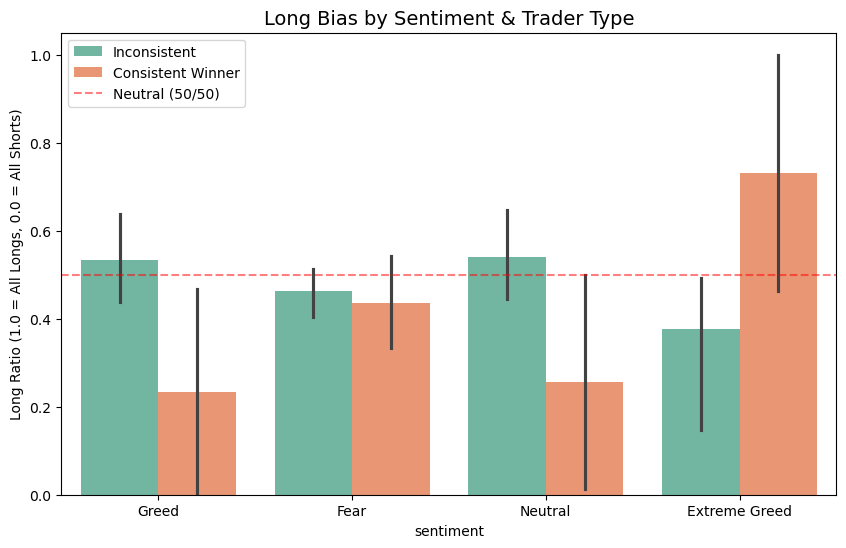

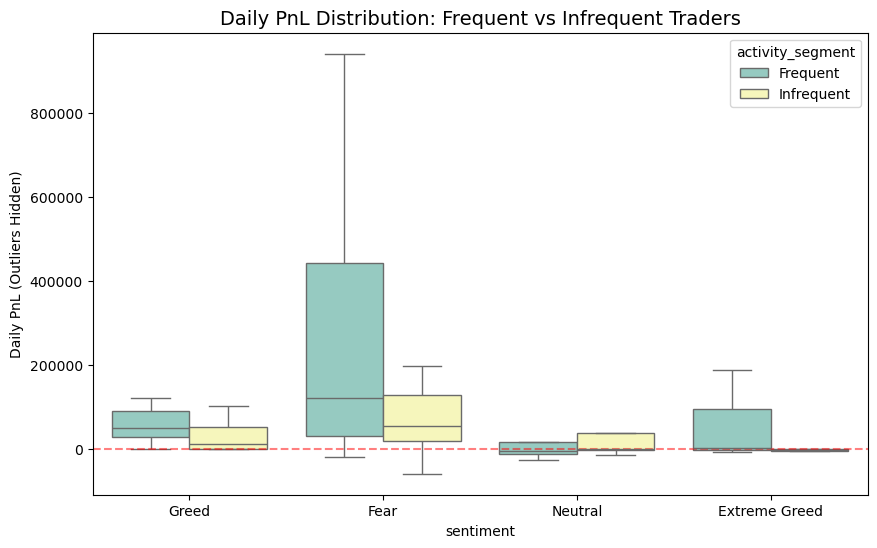

In [32]:
# Visual 2: How do different segments adjust their Long/Short bias?
plt.figure(figsize=(10, 6))
sns.barplot(
    data=analysis_df, 
    x='sentiment', 
    y='long_ratio', 
    hue='profitability_segment', 
    palette='Set2'
)
plt.title('Long Bias by Sentiment & Trader Type', fontsize=14)
plt.ylabel('Long Ratio (1.0 = All Longs, 0.0 = All Shorts)')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Neutral (50/50)')
plt.legend()
plt.show()

# Visual 3: Do frequent traders get punished on Fear days compared to Greed days?
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=analysis_df, 
    x='sentiment', 
    y='daily_pnl', 
    hue='activity_segment', 
    showfliers=False, # Hiding extreme outliers so the boxplot is readable
    palette='Set3'
)
plt.title('Daily PnL Distribution: Frequent vs Infrequent Traders', fontsize=14)
plt.ylabel('Daily PnL (Outliers Hidden)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

print("Building the Predictive Model...")

# 1. Feature Engineering: Create the Target Variable (Next Day PnL)
# We shift the daily_pnl up by 1 row per account to get "tomorrow's" PnL
analysis_df = analysis_df.sort_values(by=['account', 'date'])
analysis_df['next_day_pnl'] = analysis_df.groupby('account')['daily_pnl'].shift(-1)

# Target: 1 if tomorrow is profitable, 0 if not
analysis_df['target_profitable'] = (analysis_df['next_day_pnl'] > 0).astype(int)

# Drop the last day for each trader since we don't have "tomorrow" for the final row
ml_df = analysis_df.dropna(subset=['next_day_pnl']).copy()

# 2. Encode Sentiment (Machine Learning models need numbers, not words)
# Assuming sentiment is 'Fear' or 'Greed'. Adjust if it includes 'Neutral'
ml_df['sentiment_encoded'] = np.where(ml_df['sentiment'].str.lower() == 'greed', 1, 0)

# 3. Select Features (X) and Target (y)
# Let's drop missing values in our features just to be safe
features = ['win_rate', 'avg_trade_size_usd', 'trade_count', 'long_ratio', 'sentiment_encoded']
ml_df = ml_df.dropna(subset=features)

X = ml_df[features]
y = ml_df['target_profitable']

# 4. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance (What drives profitability?)
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
display(importance)

Building the Predictive Model...

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Feature Importances:


,Feature,Importance
2,trade_count,0.351412
1,avg_trade_size_usd,0.242756
3,long_ratio,0.225892
0,win_rate,0.155846
4,sentiment_encoded,0.024093
